# Missing Values
- We have three approaches:
1. Drop Columns with missing values.
2. Imputation: Like filling mean value of the each columns.
3. An extension to Imputation: Imputation + an extra columns which show where values was missing.

    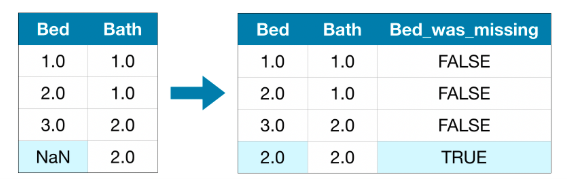

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv(r"C:\Kaggle\Intermediate_ML\melb_data.csv")

In [58]:
data.dtypes

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

In [59]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [60]:
y = data.Price

melb_predictors = data.drop(['Price'], axis=1)
X = melb_predictors.select_dtypes(exclude=['object'])
# select_dtypes function use to select columns from a dataframe based on datatypes.
# include and exclude are parameters for select_dtypes.

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def score_dataset(X_train, X_valid,y_train, y_valid):
    model = RandomForestRegressor(n_estimators=10, random_state=0)
    # n_estimators parameter will define no. of decision tree used.
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)


## Score from Approach 1: Drop Columns with Missing values

In [62]:
cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]
# List Comprehension Fromat: [expression for item in iterable if condition]
# expression get add to the list.

reduced_X_train = X_train.drop(cols_with_missing, axis=1)
reduced_X_valid = X_valid.drop(cols_with_missing, axis=1)

print("MAE from Approach 1 (Drop columns with missing values):")
print(score_dataset(reduced_X_train, reduced_X_valid, y_train, y_valid))

MAE from Approach 1 (Drop columns with missing values):
183550.22137772635


## Score from approach 2: Imputation

In [63]:
from sklearn.impute import SimpleImputer # SimpleImputer class

my_imputer = SimpleImputer() # creating object

imputed_X_train = pd.DataFrame(my_imputer.fit_transform(X_train))
imputed_X_valid = pd.DataFrame(my_imputer.transform(X_valid))
# fit(): learns statistics (like mean) from training data
# transform(): fills missing values using learned statistics
# fit_transform(): does both in one step
# transform() and fit_transform() returns NumPy array so,
# pd.DataFrame add numerical index and numerical columns name.

imputed_X_train.columns = X_train.columns
imputed_X_valid.columns = X_valid.columns

print("MAE from Approach 2 (Imputation):")
print(score_dataset(imputed_X_train, imputed_X_valid, y_train, y_valid))

MAE from Approach 2 (Imputation):
178166.46269899711


In [64]:
DF = pd.DataFrame([[1,2,3],[4,5,6]])
DF.index = ['A','B']
DF.columns = ['C','D','E']
DF

,C,D,E
A,1,2,3
B,4,5,6


In [65]:
type(imputed_X_train.columns)

pandas.Index

## Score from Approach 3: An Extension to Imputation

In [66]:
# creating copy of dataframe
X_train_plus = X_train.copy()
X_valid_plus = X_valid.copy()

# adding missing values indicator columns
for col in cols_with_missing:
    X_train_plus[col + '_was_missing'] = X_train_plus[col].isnull()
    X_valid_plus[col + '_was_missing'] = X_valid_plus[col].isnull()
# isnull() returns series or dataframe of boolean

my_imputer = SimpleImputer()
imputed_X_train_plus = pd.DataFrame(my_imputer.fit_transform(X_train_plus))
imputed_X_valid_plus = pd.DataFrame(my_imputer.transform(X_valid_plus))

imputed_X_train_plus.columns = X_train_plus.columns
imputed_X_valid_plus.columns = X_valid_plus.columns

print("MAE from Approach 3 (An Extension to Imputation):")
print(score_dataset(imputed_X_train_plus, imputed_X_valid_plus, y_train, y_valid))

MAE from Approach 3 (An Extension to Imputation):
178927.503183954


In [67]:
print(X_train.shape)

missing_val_count_by_column = X_train.isnull().sum()
print(missing_val_count_by_column[missing_val_count_by_column > 0]) # boolean filtering

(10864, 12)
Car               49
BuildingArea    5156
YearBuilt       4307
dtype: int64


# Categorical Variables
Three Approaches to handle:
1. Drop Categorical Variables
2. Ordinal Encoding: assigning each unique value to different integer.
3. One-Hot Encoding: create new columns indicating presence or absence of a value.  
it is good for nominal variables(categorical variables without any intrinsic ranking)


    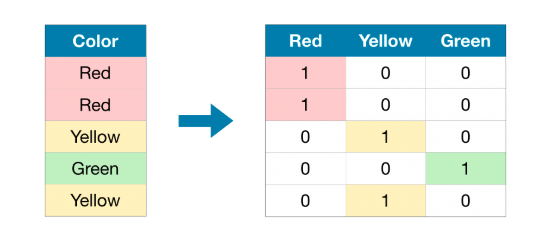

In [68]:
data = pd.read_csv(r"C:\Kaggle\Intermediate_ML\melb_data.csv")

y = data.Price
X = data.drop(['Price'], axis=1)

X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

cols_with_missing =[col for col in X_train.columns if X_train[col].isnull().any()]
# List Comprehension Fromat: [expression for item in iterable if condition]
# expression get add to the list.
# isnull() returns series or dataframe of boolean
# any() returns single boolean/series depending on the type of data.
X_train_full.drop(cols_with_missing, axis=1, inplace=True)
X_valid_full.drop(cols_with_missing, axis=1, inplace=True)

# "Cardinality" means the number of unique values in a column
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10
                        and X_train_full[cname].dtype in ['object', 'string']]
# nunique() Returns a single integer (Series) or a Series of integers (DataFrame).

numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

my_cols = low_cardinality_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

In [69]:
X_train.head()

,Type,Method,Regionname,Rooms,Distance,Postcode,Bedroom2,Bathroom,Landsize,Lattitude,Longtitude,Propertycount
12167,u,S,Southern Metropolitan,1,5.0,3182.0,1.0,1.0,0.0,-37.85984,144.9867,13240.0
6524,h,SA,Western Metropolitan,2,8.0,3016.0,2.0,2.0,193.0,-37.85800,144.9005,6380.0
8413,h,S,Western Metropolitan,3,12.6,3020.0,3.0,1.0,555.0,-37.79880,144.8220,3755.0
2919,u,SP,Northern Metropolitan,3,13.0,3046.0,3.0,1.0,265.0,-37.70830,144.9158,8870.0
6043,h,S,Western Metropolitan,3,13.3,3020.0,3.0,1.0,673.0,-37.76230,144.8272,4217.0


In [70]:
s = X_train.dtypes == 'string'
# this will return a boolean series.
object_cols = list(s[s].index)
# s[s] is boolean index it will keep value where s is true
print("Categorical variables:")
print(object_cols)

Categorical variables:
['Type', 'Method', 'Regionname']


In [71]:
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

## Score from Approach 1 (Drop categorical variables)

In [72]:
drop_X_train = X_train.select_dtypes(exclude=['string'])
drop_X_valid = X_valid.select_dtypes(exclude=['string'])
# select_dtypes() method select column based on dtype.
# include=, exclude= parameters it used and always returns a dataframe.
print("MAE from Approach 1 (Drop categorical variables):")
print(score_dataset(drop_X_train, drop_X_valid, y_train, y_valid))

MAE from Approach 1 (Drop categorical variables):
175703.48185157913


## Score from Appraoch 2 (Ordinal Encoding)

In [73]:
from sklearn.preprocessing import OrdinalEncoder

X_train_label = X_train.copy()
X_valid_label = X_valid.copy()

ordinal_encoder = OrdinalEncoder()
X_train_label[object_cols] = ordinal_encoder.fit_transform(X_train_label[object_cols])
X_valid_label[object_cols] = ordinal_encoder.transform(X_valid_label[object_cols])
# fit()	Learn category mapping
# transform() Convert categories → numbers
# fit_transform() Learn + convert

print("MAE from Approach 2 (Ordinal Encoding):")
print(score_dataset(X_train_label, X_valid_label, y_train, y_valid))

MAE from Approach 2 (Ordinal Encoding):
165936.40548390493


## Score frome Approach 3 (One-Hot Encoding)

In [74]:
from sklearn.preprocessing import OneHotEncoder

OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[object_cols]))
OH_cols_valid = pd.DataFrame(OH_encoder.transform(X_valid[object_cols]))
# fit_transform() and transform() returns sparse_output matrix by default.

OH_cols_train.index = X_train.index
OH_cols_valid.index = X_valid.index
# because of sparse_output=False fit_transform() and transform() method will return an NumPy array.

num_X_train = X_train.drop(object_cols, axis=1)
num_X_valid = X_valid.drop(object_cols, axis=1)

OH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
OH_X_valid = pd.concat([num_X_valid, OH_cols_valid], axis=1)

# Ensure all columns have string type
OH_X_train.columns = OH_X_train.columns.astype(str)
OH_X_valid.columns = OH_X_valid.columns.astype(str)

print("MAE from Approach 3 (One-Hot Encoding):")
print(score_dataset(OH_X_train, OH_X_valid, y_train, y_valid))

MAE from Approach 3 (One-Hot Encoding):
166089.4893009678


# Pipelines:
- A pipeline is simply a way to chain multiple ML steps together so they behave like one object.
- A reusable ML workflow object that behaves somewhat like a function but can learn and store state.
### Benefits:
1. Cleaner Code
2. Fewer Bugs
3. Easy to Productionize
4. More Options for Model Validation
### we can create a pipeline in three steps:
1. Define Preprocessing Steps
2. Define the Model
3. Create and Evaluate the Pipeline

In [75]:
data = pd.read_csv(r"C:\Kaggle\Intermediate_ML\melb_data.csv")
data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [76]:
data.dtypes

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

In [77]:
y = data.Price
X = data.drop(['Price'], axis=1)

X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

In [78]:
categorical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and X_train_full[cname].dtype == 'string']

numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

In [79]:
X_train.head()

,Type,Method,Regionname,Rooms,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
12167,u,S,Southern Metropolitan,1,5.0,3182.0,1.0,1.0,1.0,0.0,NaN,1940.0,-37.85984,144.9867,13240.0
6524,h,SA,Western Metropolitan,2,8.0,3016.0,2.0,2.0,1.0,193.0,NaN,NaN,-37.85800,144.9005,6380.0
8413,h,S,Western Metropolitan,3,12.6,3020.0,3.0,1.0,1.0,555.0,NaN,NaN,-37.79880,144.8220,3755.0
2919,u,SP,Northern Metropolitan,3,13.0,3046.0,3.0,1.0,1.0,265.0,NaN,1995.0,-37.70830,144.9158,8870.0
6043,h,S,Western Metropolitan,3,13.3,3020.0,3.0,1.0,2.0,673.0,673.0,1970.0,-37.76230,144.8272,4217.0


## Step 1: Define Preprocessing Steps

In [80]:
from sklearn.compose import ColumnTransformer 
# Used to apply different preprocessing to different columns/groups of columns
from sklearn.pipeline import Pipeline
# Used to combine multiple steps sequentially
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# preprocessing numerical data
numerical_transformer = SimpleImputer(strategy='constant')
# strategy='constant' will fill missing value with a constant value.
# default for numeric data is usually 0

# preprocessing categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# strategy='most_frequent' will fill missing value with most repeated value
# here we are using Pipeline class as we are 1st doing imputation then One-Hot encoding on data in a sequential way.

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)
# ('imputer', 'onehot', 'num', 'cat') are just name/labels

## Step 2: Define Model

In [81]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=0)

## Step 3: Create and Evaluate the Pipeline

In [82]:
from sklearn.metrics import mean_absolute_error

# Bundle preprcessing and modeling code in a Pipeline
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# preprocess the traning data, fit model
my_pipeline.fit(X_train, y_train)

# preprocess the validation data, predict
preds = my_pipeline.predict(X_valid)

score = mean_absolute_error(y_valid, preds)
print(f"MAE: {score}")

MAE: 160679.18917034855
